# Problème n°2: PointNet

Certains jeux de données impliquent des nuages de points dans un espace 3D. Penser par exemple à un ensemble de mesures lidar : chaque tir permet de renseigner les coordonnées d'un des points de l'objet ciblé.
Une tâche intéressante consiste à classer chacun des points du nuage en fonction de l'objet auquel il appartient. Cette tâche est considérée comme une variante de la segmentation sémantique d'images.

Ce problème introduit à une méthode directe de segmentation d'un nuage par deep learning. Elle est basée sur une architecture particulière appelée PointNet. \
Dans la première partie, on présente un jeu de données (synthétisé à la volée) impliquant des nuages de points.
Dans la seconde partie, on explore la structure et les propriétés de PointNet. Dans la troisième, on l'entraîne et dans la dernière partie, on charge les poids d'une version améliorée de PointNet (PointNet++) pour comparaison.

La cellule suivante permet les imports nécessaires:

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from random import randint
import matplotlib.pyplot as plt
import os
! pip install einops
! git clone https://github.com/medz1966/exam_2025.git
! cp exam_2025/utils/utils_probleme2.py .
from utils_probleme2 import gen_pointcloud, plot_triplets

Cloning into 'exam_2025'...
remote: Enumerating objects: 71, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 71 (delta 9), reused 5 (delta 5), pack-reused 54 (from 2)
Receiving objects: 100% (71/71), 3.69 MiB | 6.68 MiB/s, done.
Resolving deltas: 100% (21/21), done.


## Partie I : un exemple de PointCLoud data

Pour construire le jeu de données, on simule un terrain couvert de deux types de bâtiments : des immeubles de forme rectangulaire aux toits plats et des igloos (dômes). Pour créer les nuages, on échantillonne les surfaces vues du ciel (les murs des bâtiments rectangulaires ne sont pas échantillonnées), en favorisant les zones d'altitude non nulles.
Le but est de distinguer les igloos du reste (sol et toits des bâtiments). Il s'agit donc d'une segmentation binaire.

0


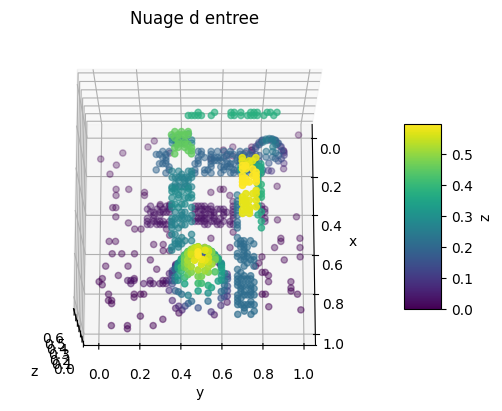

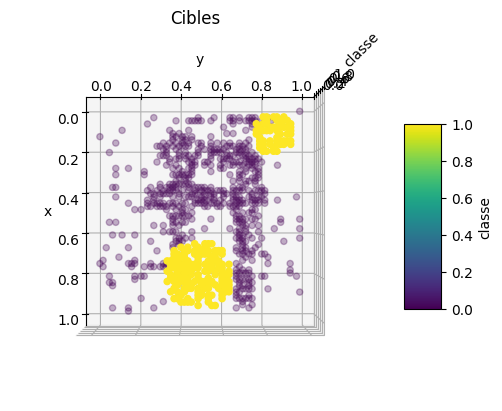

1


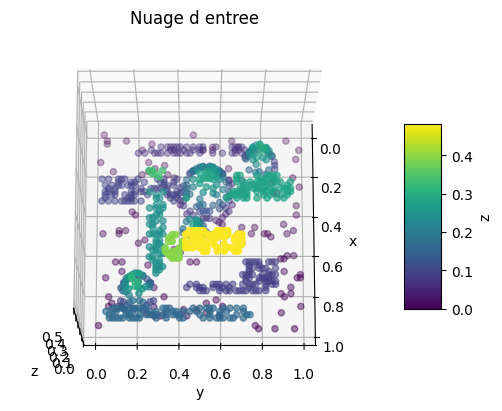

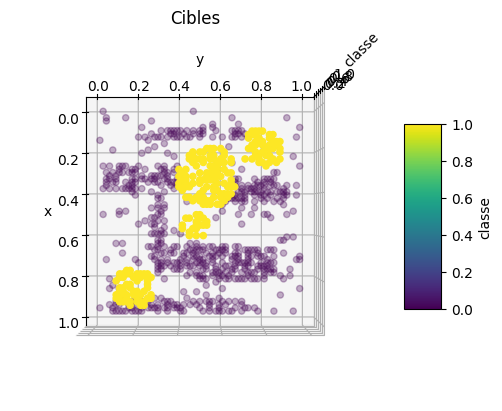

2


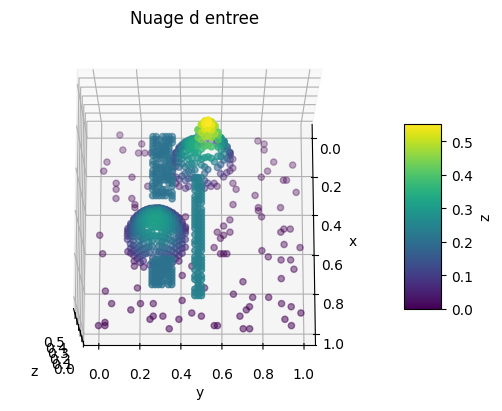

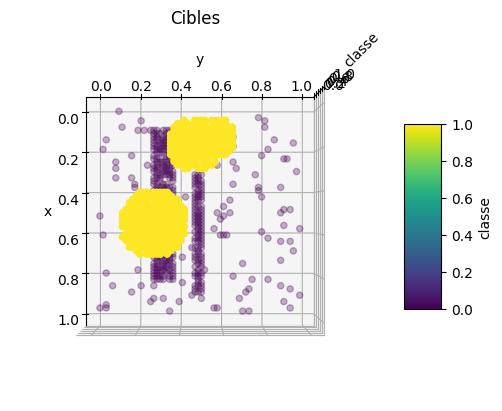

3


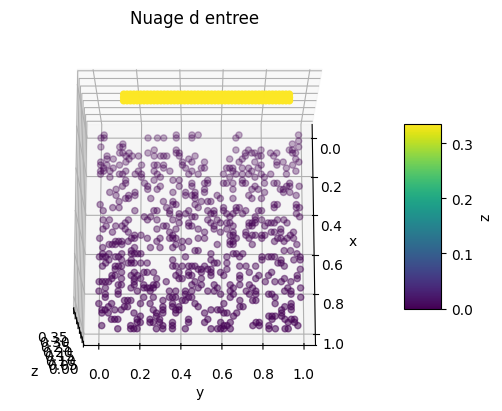

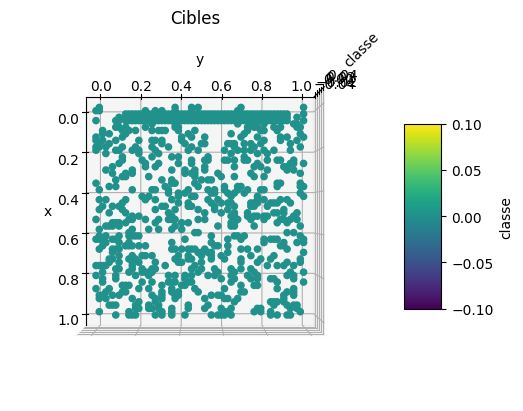

4


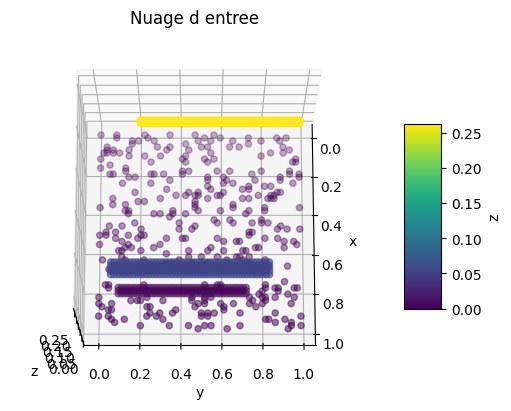

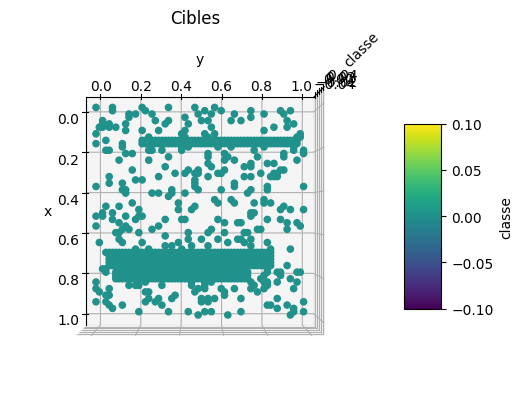

5


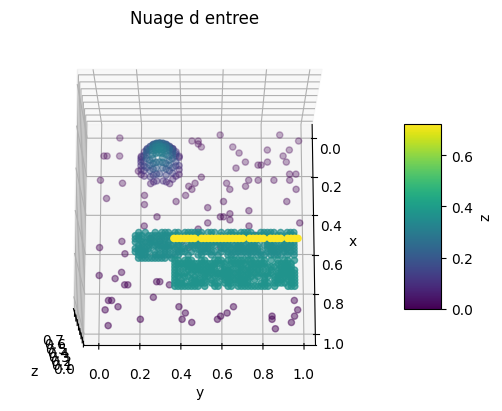

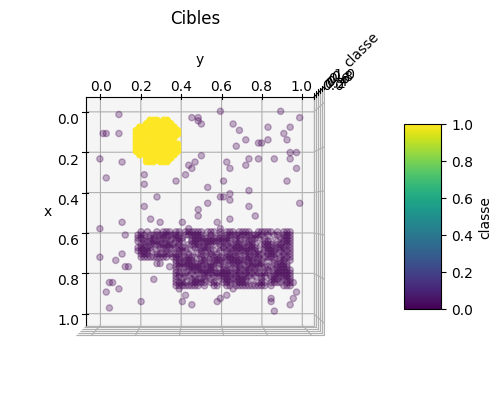

In [2]:
batch_size = 6
input_points, target_list, target_points  = gen_pointcloud(batch_size)


for i in range(batch_size):
  print(i)
  # Représentation 3D des nuages de points et
  # les paramètres elev et azim permettent de changer l'angle de vue
  plot_triplets(input_points[i].transpose(0,1).cpu(),
                elev=75, azim=0)

  # Cibles : les points appartenant aux toitures d'igloos sont
  # dans la classe 1, les autres, dans la classe 0.
  plot_triplets(target_points[i].transpose(0,1).cpu(),
                title='Cibles',
                cbar_label='classe')

  # Note: target_points contient non seulement les classes
  # mais aussi les coordonnées x et y des points, pour
  # faciliter leur visualisation

**Q1** A quoi correspondent les différentes dimensions de *input_points* ?

Lors de l’appel à `gen_pointcloud(batch_size)`, la sortie `input_points` a généralement la forme :


(batch_size, 3, nb_points)


- **Dimension 0** : la taille du batch (ici, 6)  
- **Dimension 1** : les coordonnées \((x, y, z)\)  
- **Dimension 2** : le nombre de points dans chaque nuage  

Concrètement, pour chaque élément du batch, on a un nuage de points avec trois coordonnées par point.

**Q2** Les points d'un nuage sont-ils rangés dans un ordre particulier ?

**Réponse concise :** Non, les points ne sont pas rangés dans un ordre particulier. Dans un nuage de points 3D, il n’y a pas d’organisation « en grille » comme pour une image ; les points sont simplement un ensemble $$(x_i, y_i, z_i)$$. Ainsi, on peut les permuter librement sans perdre d’information géométrique.

**Q3** (question ouverte). Si vous deviez traiter le problème avec un FCN ou un ViT (Visual Transformer), que feriez-vous ?

Pour qu’un FCN (réseau de neurones convolutifs) ou un ViT (transformer pour images) puisse traiter un nuage de points 3D, on doit convertir ces points en un format plus adapté :

1. **Images multiples (multi-view)**  
   - On prend plusieurs vues 2D du nuage de points (depuis différents angles).  
   - On applique ensuite un modèle (FCN ou ViT) sur ces images et on combine les résultats.

2. **Voxelisation**  
   - On transforme l’espace 3D en petites “cases” (voxels), un peu comme des pixels en 3D.  
   - On peut alors utiliser un FCN 3D ou une version 3D d’un ViT pour segmenter ce volume.

3. **Transformers 3D**  
   - On traite chaque point comme un “token” (une sorte de mot) contenant ses coordonnées, etc.  
   - On applique un mécanisme d’attention (similaire au ViT) spécifiquement adapté aux points 3D.

Dans tous les cas, l’idée est de changer la représentation brute (points 3D) en un format exploitable par ces architectures.

## Partie II : le modèle PointNet

Dans cette partie, on s'intéresse à la propriété principale d'un réseau PointNet : l'utilisation d'opérations invariantes par rapport à l'ordre dans lequel les points sont présentés au réseau.

In [17]:
from utils_probleme2 import PointNetSegHead
pointnet = PointNetSegHead(num_points=800, num_global_feats=1024, m=2).cuda()

input_points, target_list, _ = gen_pointcloud(batch_size)
input_points = input_points.cuda()
output, _, _ = pointnet(input_points)

**Q1** La sortie du modèle PointNet correspond au premier tenseur du *tuple* fourni la fonction *forward* de *pointnet*. A quoi correspondent les différentes dimensions de *output* ? Quel est l'effet d'une permutation des points contenus dans *inputs_points* sur la sortie ? Répondre :

- en vous référant à l'article [l'article](https://arxiv.org/abs/1612.00593) qui introduit ce réseau (citer dans le texte).
- à partir de tests à effectuer dans la cellule de code suivante (utiliser torch.randperm pour générer des permutations sur les entrées)

### 1) À quoi correspondent les dimensions de `output` ?

Lorsqu’on applique PointNet en mode *segmentation*, la sortie est un tenseur de forme :

(batch_size, num_points, num_classes)

- **`batch_size`** : nombre d’exemples dans le lot (batch).  
- **`num_points`** : nombre de points dans chaque nuage.  
- **`num_classes`** : nombre de classes à prédire pour chaque point (dans votre exemple, 2 classes : igloo ou pas igloo).

Ainsi, chaque entrée (nuage de points) produit une prédiction par point, sous la forme de scores ou de probabilités pour les différentes classes.

---

### 2) Quel est l’effet d’une permutation des points sur la sortie ?

L’article de Qi et al. (section 4.2 « PointNet Architecture ») insiste sur la **symétrie** du réseau par rapport à l’ordre des points. En particulier :

- Le module clé de PointNet est un **max pooling** sur les caractéristiques (features) de chaque point.  
- Cette opération de *pooling* ne dépend pas de l’ordre d’arrivée des points : c’est une **fonction symétrique**.  
- Par conséquent, **si on permute les points d’entrée**, la sortie globale (et donc la segmentation) **reste identique**.

**En pratique**, vous pouvez vérifier cette invariance :
1. Permutez aléatoirement l’ordre des points dans `inputs_points` (par exemple avec `torch.randperm`).
2. Comparez la prédiction du modèle (les valeurs de `output`) avant et après la permutation.  
3. Vous constaterez qu’elle ne change pas, validant la propriété « permutation invariance » de PointNet.  

C’est un atout majeur de PointNet pour les nuages de points 3D, qui n’ont pas d’ordre « naturel » (contrairement aux pixels d’une image).

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from utils_probleme2 import gen_pointcloud

class SimplePointNet(nn.Module):
    def __init__(self, num_points, num_classes):
        super(SimplePointNet, self).__init__()
        self.num_points = num_points
        self.num_classes = num_classes

        # Couches de transformation
        self.fc1 = nn.Linear(3, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 256)
        self.fc4 = nn.Linear(256, 512)
        self.fc5 = nn.Linear(512, 1024)
        self.fc6 = nn.Linear(1024, self.num_classes)  # Modification pour correspondre au nombre de classes

    def forward(self, x):
        x = x.transpose(2, 1)  # Transposition pour obtenir (batch_size, num_points, 3)

        # Appliquer des couches fully connected
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = F.relu(self.fc5(x))

        # Appliquer le max pooling sur les caractéristiques extraites de chaque point
        x = torch.max(x, 2)[0]  # max pooling sur la dimension des points (2ème dimension)

        # Résizer la sortie pour que ce soit compatible avec la couche suivante
        x = x.view(x.size(0), -1)  # Assurez-vous que la sortie a la forme (batch_size, 1024)

        # Finalisation de la prédiction
        x = self.fc6(x)  # La couche finale pour prédire les classes
        return x

# Initialisation du modèle simplifié
model = SimplePointNet(num_points=800, num_classes=2).cuda()

# Génération des données d'exemple
batch_size = 6
input_points, target_list, _ = gen_pointcloud(batch_size)
input_points = input_points.cuda()

# Calcul de la sortie initiale
output = model(input_points)

# Permutation des indices des points
perm = torch.randperm(input_points.size(2)).cuda()
permuted_input_points = input_points[:, :, perm]

# Calcul de la sortie après permutation
permuted_output = model(permuted_input_points)

# Comparaison des sorties avant et après permutation
output_equal = torch.allclose(output, permuted_output, atol=1e-5)

# Affichage des résultats
print(f"Les sorties sont-elles identiques après permutation des points ? {output_equal}")


RuntimeError: mat1 and mat2 shapes cannot be multiplied (6x800 and 1024x2)

**Q2** L'architecture de *pointnet* est décrite dans la Figure 2 de l'article (voir ci-dessous) évoqué à la question précédente. En dehors des opérations notées "input transform" et "feature transform", dont la compréhension est plus délicate, quelles sont les différentes opérations conduisant à une segmentation ? Que signifie le terme "shared" et expliquer en quoi ces opérations sont invariantes par rapport à l'ordre de présentation des points.

<img src= https://miro.medium.com/v2/resize:fit:1100/format:webp/1*lFnrIqmV_47iRvQcY3dB7Q.png >

Dans **PointNet**, les principales opérations menant à la segmentation (en dehors de "input transform" et "feature transform") sont les suivantes :

1. **MLP partagés (Multilayer Perceptrons)** : Le même MLP est appliqué à chaque point du nuage de points, garantissant que chaque point est traité de manière identique. Le terme **"partagé"** signifie que les mêmes poids sont utilisés pour chaque point, ce qui assure **l'invariance** par rapport à l'ordre des points.

2. **Max pooling global** : Après que les points ont été traités par les MLP partagés, un max pooling global est appliqué pour agréger les caractéristiques de tous les points. Cette opération capture les informations globales, est **invariante par rapport à l'ordre des points** et supprime toute dépendance à l'ordre des points.

3. **Classification/Segmentation** : Les caractéristiques agrégées sont ensuite passées par des couches entièrement connectées pour classer ou segmenter chaque point.

Ces opérations garantissent que le modèle est **invariant à l'ordre des points** dans l'entrée.

## Partie III

Dans cette partie, on se propose d'entraîner un PointNet. Pour ce faire, on utilisera une fonction de coût spécifique (voir cellule ci-dessous).

**Consignes :**

1) Entraîner un PointNet sur quelques centaines d'époques.

2) Afficher à chaque époque la justesse des prédictions

3) Charger les poids d'un réseau entraîné sur 500 époques, stockés dans le fichier **pointnet_500_ep.pth** du répertoire https://huggingface.co/nanopiero/pointnet_igloos.

Visualiser les sorties de ce modèle-là en complétant le la dernière cellule de code du calepin.


In [22]:
optimizer = torch.optim.Adam(pointnet.parameters(),
                             lr=0.0001, betas=(0.9, 0.999))

# manually set alpha weights
alpha = np.array([0.2, 0.8])
gamma = 1
loss_fn = PointNetSegLoss(alpha=alpha, gamma=gamma, dice=True).cuda()

# exemple d'utilisation de PointNetSegLoss:
# La transposition permet de repasser la dimension relative
# aux probabilités en dernier, comme avec torch.nn.CrossEntropyLoss
proba_pred_list = outputs.transpose(1,2)
loss_fn(proba_pred_list, target_list)

TypeError: cannot assign 'numpy.ndarray' object to buffer 'weight' (torch Tensor or None required)

In [ ]:
batch_size = 64
n_epochs = 200
n_batch_per_epoch = 10


for epoch in range(1, n_epochs):
  print('epoch : ', epoch)
  for batch in range(1,n_batch_per_epoch):
    ...

In [ ]:
input_points, target_list , target_points = gen_pointcloud(6)

# Il faut construire les prédictions.
proba_pred_list, _, _ = pointnet2.cuda()(input_points.to(device))
pred_list = proba_pred_list.transpose(1,2).max(1)[1].cpu()

# Accuracy:
...
# Tracé

for i in range(6):
  print(i)
  plot_triplets(input_points[i].transpose(0,1), elev=75, azim=0)
  plot_triplets(target_points[i].transpose(0,1),
                title='Cibles',
                cbar_label='classe')
  plot_triplets(...,
                title='Predictions',
                cbar_label='classe')
